<a href="https://colab.research.google.com/github/220109cse-creat/220109-knn/blob/main/220109_knn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 12})

print('libraries imported successfully')

libraries imported successfully


In [2]:
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
df['diagnosis'] = df['target'].map({0: 'Malignant', 1: 'Benign'})

print(f'Dataset loaded: {df.shape[0]} samples, {df.shape[1]-2} features')
print(f'\n Class Distribution:')
print(df['diagnosis'].value_counts())
print(f'\n First 5 rows:')
df.head()

Dataset loaded: 569 samples, 30 features

 Class Distribution:
diagnosis
Benign       357
Malignant    212
Name: count, dtype: int64

 First 5 rows:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,Malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,Malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,Malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,Malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,Malignant


In [4]:
print('Dataset Info:')
print(f'Shape: {df.shape}')
print(f'Missing values: {df.isnull().sum().sum()}')
print(f'Data types:\n{df.dtypes.value_counts()}')
print('\n Statistical Summary:')
df.describe().round(2)

Dataset Info:
Shape: (569, 32)
Missing values: 0
Data types:
float64    30
int64       1
object      1
Name: count, dtype: int64

 Statistical Summary:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,...,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00
mean,14.13,19.29,91.97,654.89,0.10,0.10,0.09,0.05,0.18,0.06,...,25.68,107.26,880.58,0.13,0.25,0.27,0.11,0.29,0.08,0.63
std,3.52,4.30,24.30,351.91,0.01,0.05,0.08,0.04,0.03,0.01,...,6.15,33.60,569.36,0.02,0.16,0.21,0.07,0.06,0.02,0.48
min,6.98,9.71,43.79,143.50,0.05,0.02,0.00,0.00,0.11,0.05,...,12.02,50.41,185.20,0.07,0.03,0.00,0.00,0.16,0.06,0.00
25%,11.70,16.17,75.17,420.30,0.09,0.06,0.03,0.02,0.16,0.06,...,21.08,84.11,515.30,0.12,0.15,0.11,0.06,0.25,0.07,0.00
50%,13.37,18.84,86.24,551.10,0.10,0.09,0.06,0.03,0.18,0.06,...,25.41,97.66,686.50,0.13,0.21,0.23,0.10,0.28,0.08,1.00
75%,15.78,21.80,104.10,782.70,0.11,0.13,0.13,0.07,0.20,0.07,...,29.72,125.40,1084.00,0.15,0.34,0.38,0.16,0.32,0.09,1.00
max,28.11,39.28,188.50,2501.00,0.16,0.35,0.43,0.20,0.30,0.10,...,49.54,251.20,4254.00,0.22,1.06,1.25,0.29,0.66,0.21,1.00


In [5]:
X = df.drop(columns=['target', 'diagnosis'])
y = df['target']

print(f'Features shape : {X.shape}')
print(f'Target shape   : {y.shape}')
print(f'Classes        : {dict(zip([0,1], data.target_names))}')

Features shape : (569, 30)
Target shape   : (569,)
Classes        : {0: np.str_('malignant'), 1: np.str_('benign')}


In [6]:
imputer = SimpleImputer(strategy='mean')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

print(f'Missing values after imputation: {X_imputed.isnull().sum().sum()}')
categorical_cols = X_imputed.select_dtypes(include=['object']).columns.tolist()
if categorical_cols:
    le = LabelEncoder()
    for col in categorical_cols:
        X_imputed[col] = le.fit_transform(X_imputed[col])
    print(f'Encoded {len(categorical_cols)} categorical column(s): {categorical_cols}')
else:
    print('No categorical columns — all features are numeric.')

Missing values after imputation: 0
No categorical columns — all features are numeric.


In [10]:
RANDOM_STATE = 42
X_train, X_temp, y_train, y_temp = train_test_split(
    X_imputed, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

print(f'Data Split (70/15/15):')
print(f'Train      : {X_train.shape[0]} samples ({X_train.shape[0]/len(y)*100:.1f}%)')
print(f'Validation : {X_val.shape[0]} samples ({X_val.shape[0]/len(y)*100:.1f}%)')
print(f'Test       : {X_test.shape[0]} samples ({X_test.shape[0]/len(y)*100:.1f}%)')
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on train only
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print('Feature scaling complete (StandardScaler applied).')
print(f'Mean  (train, sample): {X_train_scaled.mean(axis=0)[:3].round(4)}')
print(f'Std   (train, sample): {X_train_scaled.std(axis=0)[:3].round(4)}')

Data Split (70/15/15):
Train      : 398 samples (69.9%)
Validation : 85 samples (14.9%)
Test       : 86 samples (15.1%)
Feature scaling complete (StandardScaler applied).
Mean  (train, sample): [-0.  0.  0.]
Std   (train, sample): [1. 1. 1.]


Optimal K (lowest error on validation set): 5
Error Rate at K=5: 0.0118
Accuracy  at K=5: 0.9882


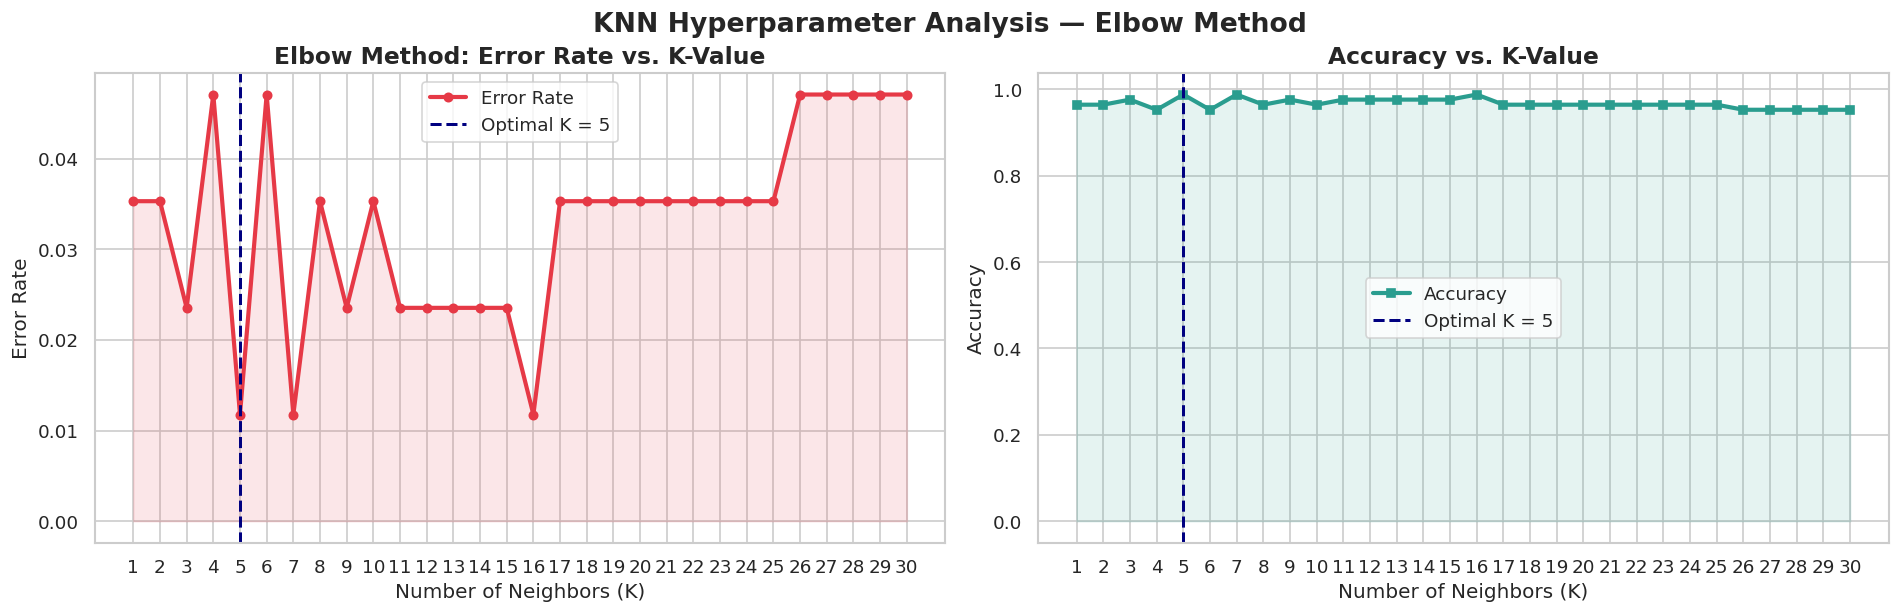

Elbow Method plots saved!


In [13]:
error_rates = []
accuracy_rates = []
k_range = range(1, 31)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    pred = knn.predict(X_val_scaled)
    error_rates.append(np.mean(pred != y_val))
    accuracy_rates.append(accuracy_score(y_val, pred))

optimal_k = k_range[np.argmin(error_rates)]
print(f'Optimal K (lowest error on validation set): {optimal_k}')
print(f'Error Rate at K={optimal_k}: {min(error_rates):.4f}')
print(f'Accuracy  at K={optimal_k}: {max(accuracy_rates):.4f}')
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(k_range, error_rates, color='#E63946', linewidth=2.5,
             marker='o', markersize=5, label='Error Rate')
axes[0].axvline(x=optimal_k, color='navy', linestyle='--', linewidth=1.8,
                label=f'Optimal K = {optimal_k}')
axes[0].fill_between(k_range, error_rates, alpha=0.12, color='#E63946')
axes[0].set_title('Elbow Method: Error Rate vs. K-Value', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Neighbors (K)', fontsize=12)
axes[0].set_ylabel('Error Rate', fontsize=12)
axes[0].legend()
axes[0].set_xticks(list(k_range))

axes[1].plot(k_range, accuracy_rates, color='#2A9D8F', linewidth=2.5,
             marker='s', markersize=5, label='Accuracy')
axes[1].axvline(x=optimal_k, color='navy', linestyle='--', linewidth=1.8,
                label=f'Optimal K = {optimal_k}')
axes[1].fill_between(k_range, accuracy_rates, alpha=0.12, color='#2A9D8F')
axes[1].set_title('Accuracy vs. K-Value', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Neighbors (K)', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].legend()
axes[1].set_xticks(list(k_range))

plt.tight_layout()
plt.suptitle('KNN Hyperparameter Analysis — Elbow Method', fontsize=16,
             fontweight='bold', y=1.02)
plt.savefig('elbow_method.png', bbox_inches='tight', dpi=150)
plt.show()
print('Elbow Method plots saved')


In [15]:
param_grid = {
    'n_neighbors': list(range(1, 21)),        # K values to test
    'weights'    : ['uniform', 'distance'],   # Weighting strategy
    'metric'     : ['minkowski', 'euclidean', 'manhattan']  # Distance metric
}

knn_base = KNeighborsClassifier()
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    estimator  = knn_base,
    param_grid = param_grid,
    cv         = cv,
    scoring    = 'accuracy',
    n_jobs     = -1,
    verbose    = 1
)

grid_search.fit(X_train_scaled, y_train)

print('\n GridSearchCV complete')
print(f'Best Parameters : {grid_search.best_params_}')
print(f'Best CV Accuracy: {grid_search.best_score_:.4f}')
best_params = grid_search.best_params_
knn_final = KNeighborsClassifier(**best_params)
knn_final.fit(X_train_scaled, y_train)

print(f'Final KNN model trained with: {best_params}')

Fitting 5 folds for each of 120 candidates, totalling 600 fits

 GridSearchCV complete
Best Parameters : {'metric': 'manhattan', 'n_neighbors': 6, 'weights': 'uniform'}
Best CV Accuracy: 0.9774
Final KNN model trained with: {'metric': 'manhattan', 'n_neighbors': 6, 'weights': 'uniform'}


In [17]:
y_pred       = knn_final.predict(X_test_scaled)
y_pred_proba = knn_final.predict_proba(X_test_scaled)[:, 1]

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
auc       = roc_auc_score(y_test, y_pred_proba)
print('EVALUATION METRICS (Test Set)')
print(f'Accuracy: {accuracy:.4f}  ({accuracy*100:.2f}%)')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-Score: {f1:.4f}')
print(f'AUC-ROC: {auc:.4f}')

print('\nFull Classification Report:')
print(classification_report(y_test, y_pred,
      target_names=['Malignant', 'Benign']))

EVALUATION METRICS (Test Set)
Accuracy: 0.9419  (94.19%)
Precision: 0.9298
Recall: 0.9815
F1-Score: 0.9550
AUC-ROC: 0.9742

Full Classification Report:
              precision    recall  f1-score   support

   Malignant       0.97      0.88      0.92        32
      Benign       0.93      0.98      0.95        54

    accuracy                           0.94        86
   macro avg       0.95      0.93      0.94        86
weighted avg       0.94      0.94      0.94        86



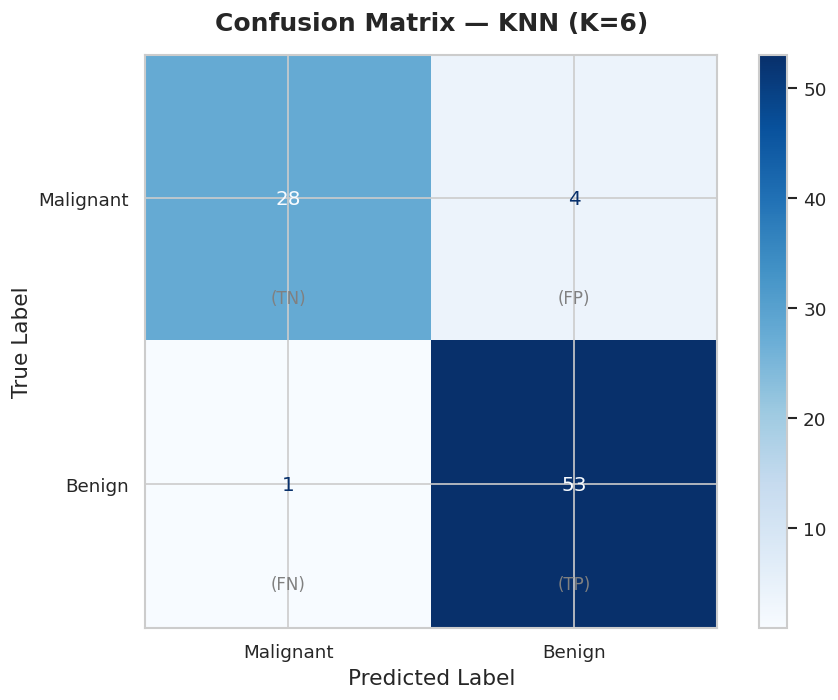

Confusion matrix saved!


In [18]:
cm = confusion_matrix(y_test, y_pred)
labels = ['Malignant', 'Benign']

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, cmap='Blues', colorbar=True)

ax.set_title(f'Confusion Matrix — KNN (K={best_params["n_neighbors"]})',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Predicted Label', fontsize=13)
ax.set_ylabel('True Label', fontsize=13)

for i, row_label in enumerate(labels):
    for j, col_label in enumerate(labels):
        cell_type = (
            'TP' if i == 1 and j == 1 else
            'TN' if i == 0 and j == 0 else
            'FP' if i == 0 and j == 1 else 'FN'
        )
        ax.text(j, i + 0.35, f'({cell_type})',
                ha='center', va='center',
                fontsize=10, color='gray')

plt.tight_layout()
plt.savefig('confusion_matrix.png', bbox_inches='tight', dpi=150)
plt.show()
print('Confusion matrix saved!')

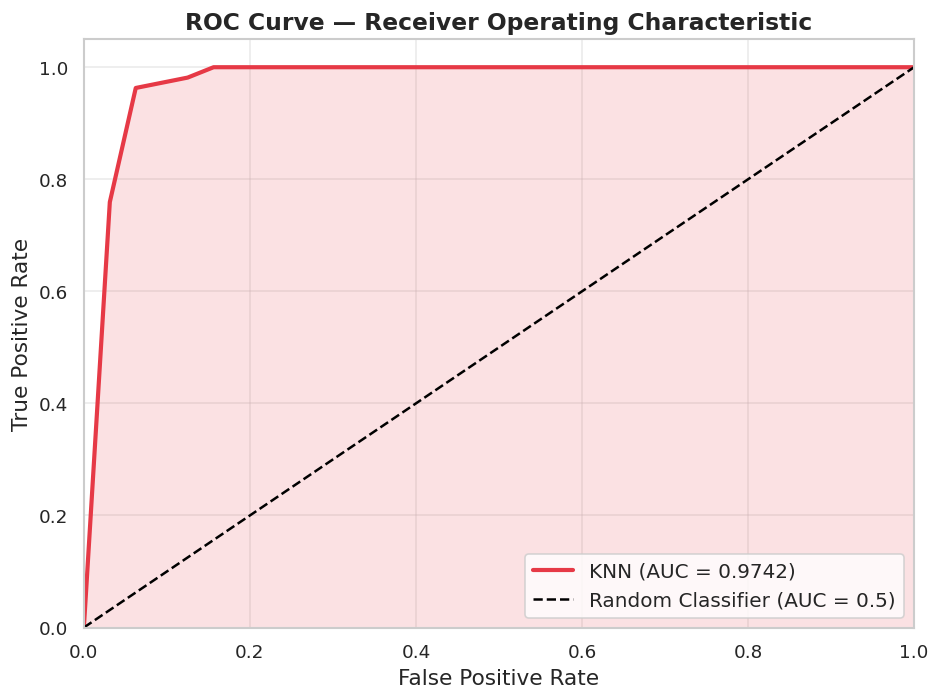

ROC Curve saved!


In [22]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='#E63946', linewidth=2.5,
        label=f'KNN (AUC = {auc:.4f})')
ax.plot([0, 1], [0, 1], color='black', linestyle='--',
        linewidth=1.5, label='Random Classifier (AUC = 0.5)')
ax.fill_between(fpr, tpr, alpha=0.15, color='#E63946')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate', fontsize=13)
ax.set_title('ROC Curve — Receiver Operating Characteristic',
             fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=12)
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('roc_curve.png', bbox_inches='tight', dpi=150)
plt.show()
print('ROC Curve saved')

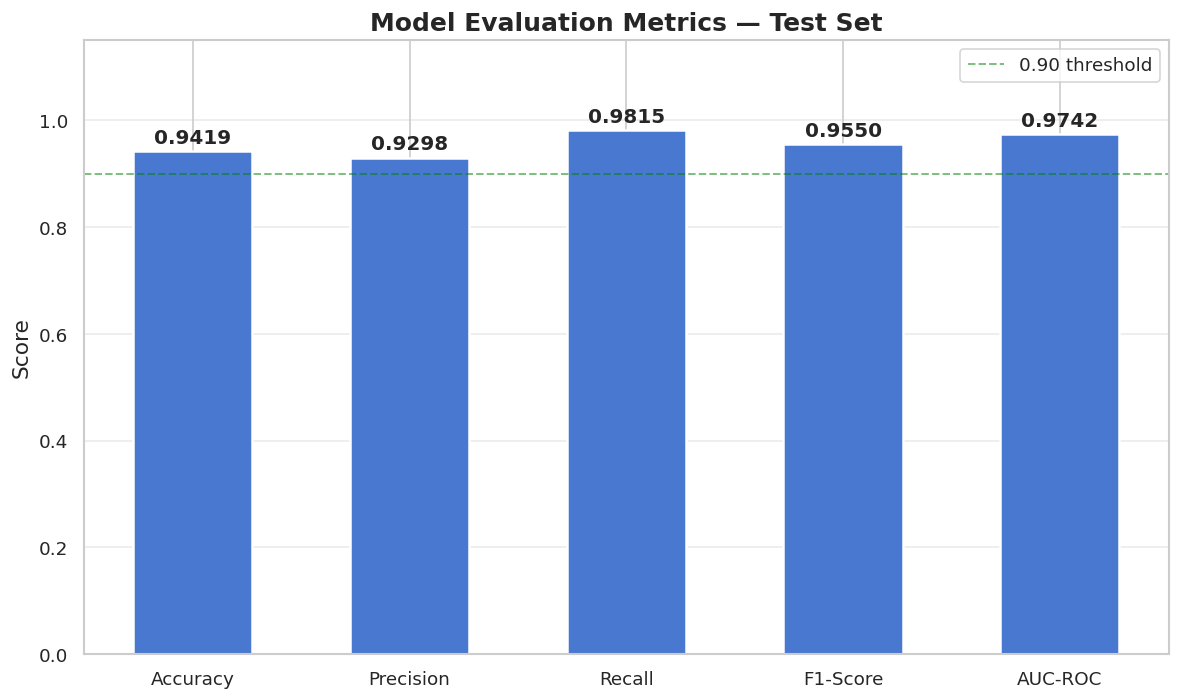

Evaluation metrics chart saved!


In [24]:
metrics_names  = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
metrics_values = [accuracy, precision, recall, f1, auc]
colors = ['#264653', '#2A9D8F', '#E9C46A', '#F4A261', '#E63946']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(metrics_names, metrics_values,
              edgecolor='white', linewidth=1.5, width=0.55)

for bar, val in zip(bars, metrics_values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.008,
            f'{val:.4f}', ha='center', va='bottom',
            fontsize=12, fontweight='bold')

ax.set_ylim([0, 1.15])
ax.set_ylabel('Score', fontsize=13)
ax.set_title('Model Evaluation Metrics — Test Set',
             fontsize=15, fontweight='bold')
ax.axhline(y=0.9, color='green', linestyle='--',
           linewidth=1.2, alpha=0.5, label='0.90 threshold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('evaluation_metrics.png', bbox_inches='tight', dpi=150)
plt.show()
print('Evaluation metrics chart saved')

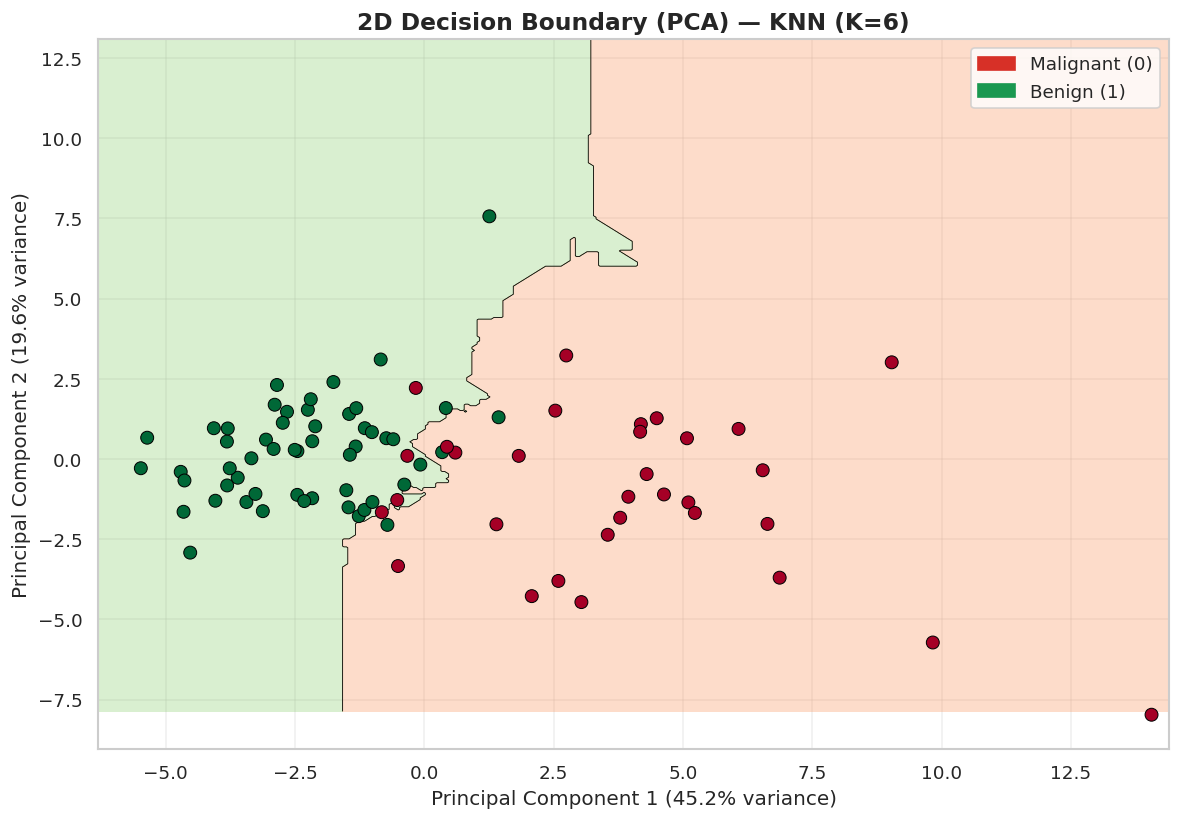

Decision boundary plot saved


In [25]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_2d = pca.fit_transform(X_train_scaled)
X_test_2d  = pca.transform(X_test_scaled)

knn_2d = KNeighborsClassifier(**best_params)
knn_2d.fit(X_train_2d, y_train)

h = 0.05
x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

Z = knn_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot
fig, ax = plt.subplots(figsize=(10, 7))
ax.contourf(xx, yy, Z, alpha=0.3,
            cmap=plt.cm.RdYlGn, levels=[-0.5, 0.5, 1.5])
ax.contour(xx, yy, Z, colors='black', linewidths=0.5, levels=[0.5])

scatter = ax.scatter(X_test_2d[:, 0], X_test_2d[:, 1],
                     c=y_test, cmap=plt.cm.RdYlGn,
                     edgecolors='black', linewidths=0.6,
                     s=60, zorder=3)

ax.set_xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)',
              fontsize=12)
ax.set_ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)',
              fontsize=12)
ax.set_title(f'2D Decision Boundary (PCA) — KNN (K={best_params["n_neighbors"]})',
             fontsize=14, fontweight='bold')

patch0 = mpatches.Patch(color='#d73027', label='Malignant (0)')
patch1 = mpatches.Patch(color='#1a9850', label='Benign (1)')
ax.legend(handles=[patch0, patch1], fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('decision_boundary.png', bbox_inches='tight', dpi=150)
plt.show()
print('Decision boundary plot saved')

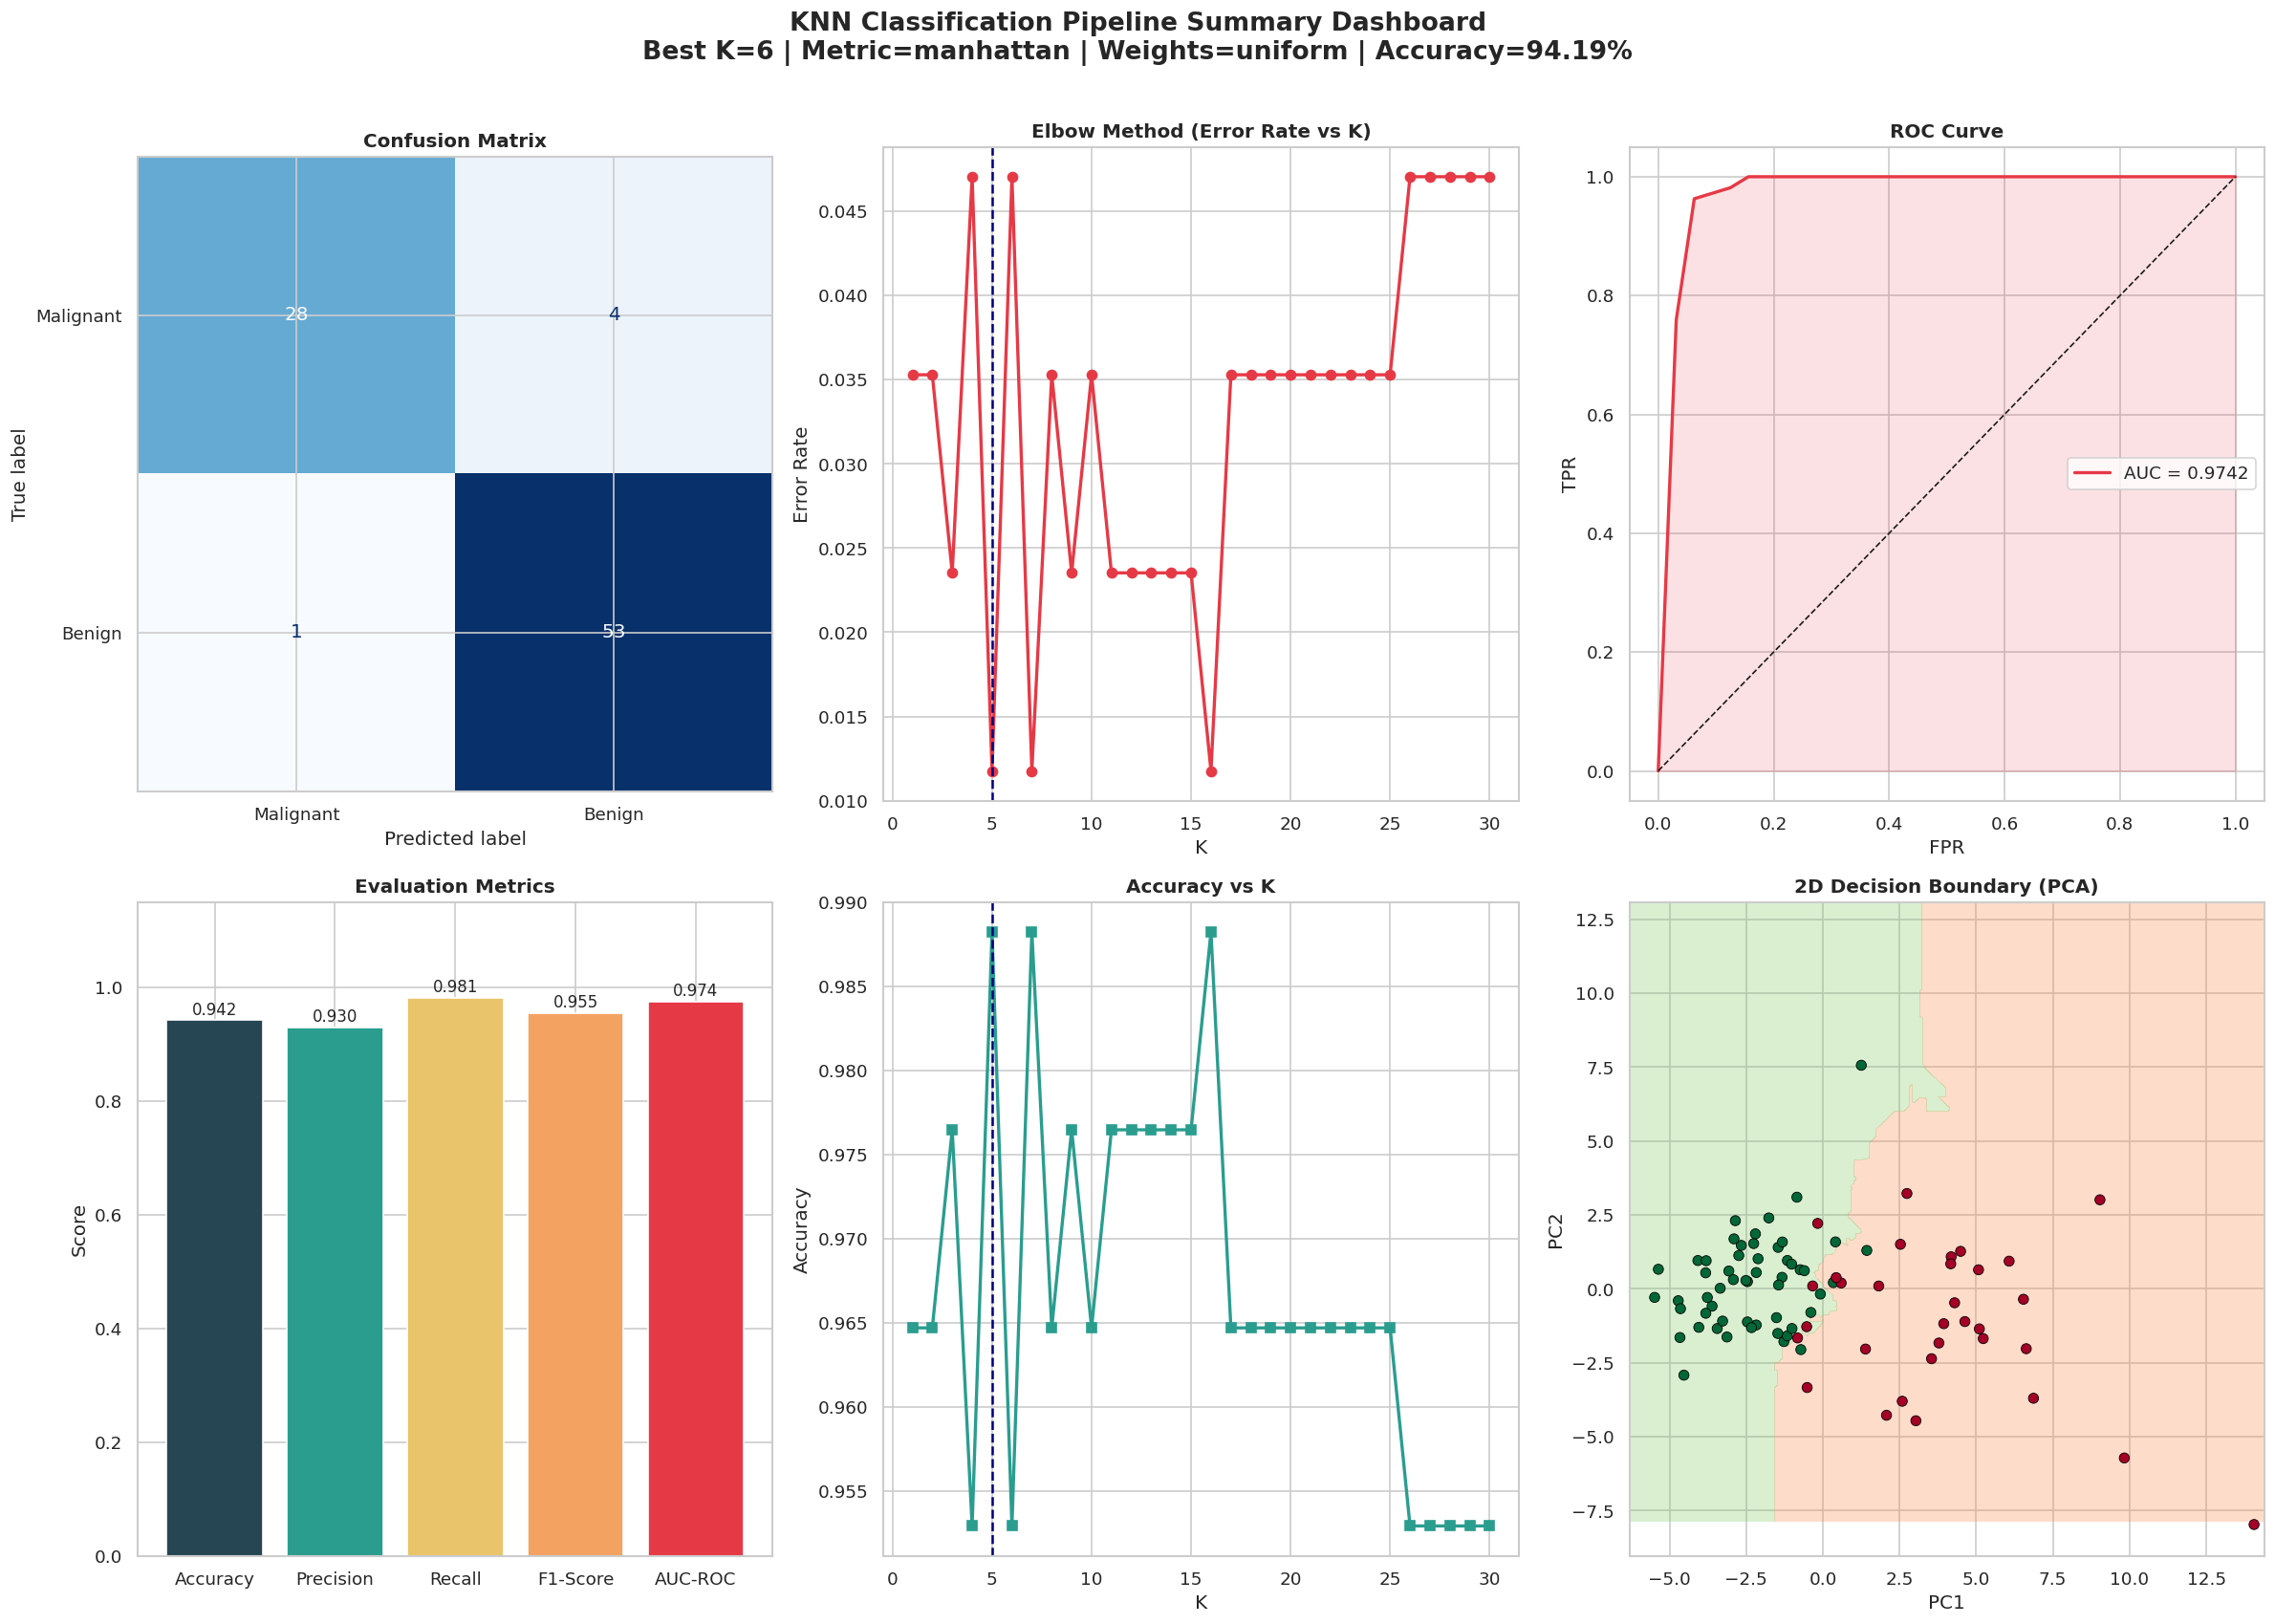

Full dashboard saved


In [26]:
fig = plt.figure(figsize=(20, 14))
ax1 = fig.add_subplot(2, 3, 1)
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm,
                                     display_labels=['Malignant', 'Benign'])
cm_display.plot(ax=ax1, cmap='Blues', colorbar=False)
ax1.set_title('Confusion Matrix', fontweight='bold')
ax2 = fig.add_subplot(2, 3, 2)
ax2.plot(k_range, error_rates, 'o-', color='#E63946', linewidth=2)
ax2.axvline(x=optimal_k, color='navy', linestyle='--')
ax2.set_title('Elbow Method (Error Rate vs K)', fontweight='bold')
ax2.set_xlabel('K'); ax2.set_ylabel('Error Rate')
ax3 = fig.add_subplot(2, 3, 3)
ax3.plot(fpr, tpr, color='#E63946', linewidth=2,
         label=f'AUC = {auc:.4f}')
ax3.plot([0,1],[0,1], 'k--', linewidth=1)
ax3.fill_between(fpr, tpr, alpha=0.15, color='#E63946')
ax3.set_title('ROC Curve', fontweight='bold')
ax3.set_xlabel('FPR'); ax3.set_ylabel('TPR')
ax3.legend()
ax4 = fig.add_subplot(2, 3, 4)
ax4.bar(metrics_names, metrics_values, color=colors, edgecolor='white')
for i, v in enumerate(metrics_values):
    ax4.text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=10)
ax4.set_ylim([0, 1.15])
ax4.set_title('Evaluation Metrics', fontweight='bold')
ax4.set_ylabel('Score')
ax5 = fig.add_subplot(2, 3, 5)
ax5.plot(k_range, accuracy_rates, 's-', color='#2A9D8F', linewidth=2)
ax5.axvline(x=optimal_k, color='navy', linestyle='--')
ax5.set_title('Accuracy vs K', fontweight='bold')
ax5.set_xlabel('K'); ax5.set_ylabel('Accuracy')
ax6 = fig.add_subplot(2, 3, 6)
ax6.contourf(xx, yy, Z, alpha=0.3,
             cmap=plt.cm.RdYlGn, levels=[-0.5, 0.5, 1.5])
ax6.scatter(X_test_2d[:, 0], X_test_2d[:, 1],
            c=y_test, cmap=plt.cm.RdYlGn,
            edgecolors='black', linewidths=0.5, s=40)
ax6.set_title('2D Decision Boundary (PCA)', fontweight='bold')
ax6.set_xlabel('PC1'); ax6.set_ylabel('PC2')

plt.suptitle(
    f'KNN Classification Pipeline Summary Dashboard\n'
    f'Best K={best_params["n_neighbors"]} | '
    f'Metric={best_params["metric"]} | '
    f'Weights={best_params["weights"]} | '
    f'Accuracy={accuracy*100:.2f}%',
    fontsize=16, fontweight='bold', y=1.01
)

plt.tight_layout()
plt.savefig('dashboard_summary.png', bbox_inches='tight', dpi=150)
plt.show()
print('Full dashboard saved')

In [28]:
print('KNN FINAL SUMMARY')
print(f'Dataset: Breast Cancer Wisconsin')
print(f'Total Samples: {len(y)}')
print(f'Features: {X.shape[1]}')
print(f'Train/Val/Test: 70% / 15% / 15%')
print(f'Best K: {best_params["n_neighbors"]}')
print(f'Best Weights: {best_params["weights"]}')
print(f'Best Metric: {best_params["metric"]}')
print(f'CV Best Score: {grid_search.best_score_:.4f}')
print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-Score: {f1:.4f}')
print(f'AUC-ROC: {auc:.4f}')
print('Saved Files:')
print('confusion_matrix.png')
print('elbow_method.png')
print('evaluation_metrics.png')
print('roc_curve.png')
print('decision_boundary.png')
print('dashboard_summary.png')


KNN FINAL SUMMARY
Dataset: Breast Cancer Wisconsin
Total Samples: 569
Features: 30
Train/Val/Test: 70% / 15% / 15%
Best K: 6
Best Weights: uniform
Best Metric: manhattan
CV Best Score: 0.9774
Accuracy: 0.9419
Precision: 0.9298
Recall: 0.9815
F1-Score: 0.9550
AUC-ROC: 0.9742
Saved Files:
confusion_matrix.png
elbow_method.png
evaluation_metrics.png
roc_curve.png
decision_boundary.png
dashboard_summary.png
